In [1]:
import numpy as np 
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 
import cmocean as cmo
import matplotlib.dates as mdates
import os 
import xarray as xr 
import datetime
from datetime import datetime, timedelta


def julian_to_datetime(julian_days, seconds_, base_julian=2440000, base_date_str="1968-05-23 00:00:00"):
    # 1. Establish your datum anchor point

    julian_days = np.asarray(julian_days)
    seconds_ = np.asarray(seconds_)
    base_date = np.datetime64(base_date_str)
    days_diff = (julian_days - base_julian) * np.timedelta64(1, 'D')
    seconds = seconds_ * np.timedelta64(1, 'ms')
    dates = base_date + days_diff + seconds
    return dates

In [2]:

folder  = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/CSF20_Shallows_Time_Series/"

# Print files in this folder

files = os.listdir(folder)
print("Files in folder:", files)

for file in files:
    fn = os.path.join(folder, file)
    if os.path.isfile(fn):
        print(file)
        # dst= xr.open_dataset(fn, decode_times=False)
        # print(dst)

        # print('\n\n')

# CSF20SPT01wh-b.nc # ADCP 
# CSF20SC201pt-b.nc
# CSF20SC104ls-s.nc
# CSF20SPT01wh-s.nc
# CSF20SC104ls-b.nc
# CSF20SC103Tu.nc
# CSF20SC201pt-wvs.nc
# CSF20SC101ctd.nc
# CSF20SC202vec-s.nc
# CSF20SC201pt-s.nc
# CSF20SC102alt.nc
# CSF20SC202vec-b.nc

        # vec, Nortek's Acoustic Doppler Velocimeter; alt, EofE Ultrasonics' altimeter; 
        # wh, RDInstrument's acoustic doppler current profile current data; 
        # pt, RBR's bursting pressure sensor with temperature; 
        # ctd, RBR's CTD; 
        # Tu, RBR's Virtuoso turbidity logger; 
        # ls, Sequoia Scientific's LISST; 
        # sig, Nortek's Signature1000 ADCP). 
        # There are an additional 2-4 characters for instruments that collect in a 
        # bursting pattern to indicate whether the file includes the raw burst data (-b), 
        # the statistics of the burst (-s), or the wave data (-wvs). 
        # This indicator is omitted if there is no bursting pattern.



Files in folder: ['CSF20SPT01wh-b.nc', 'CSF20SC201pt-b.nc', 'CSF20SC104ls-s.nc', 'CSF20SPT01wh-s.nc', 'CSF20SC104ls-b.nc', 'CSF20SC103Tu.nc', 'CSF20SC201pt-wvs.nc', 'CSF20SC101ctd.nc', 'CSF20SC202vec-s.nc', 'CSF20SC201pt-s.nc', 'CSF20SC102alt.nc', 'CSF20SC202vec-b.nc']
CSF20SPT01wh-b.nc
CSF20SC201pt-b.nc
CSF20SC104ls-s.nc
CSF20SPT01wh-s.nc
CSF20SC104ls-b.nc
CSF20SC103Tu.nc
CSF20SC201pt-wvs.nc
CSF20SC101ctd.nc
CSF20SC202vec-s.nc
CSF20SC201pt-s.nc
CSF20SC102alt.nc
CSF20SC202vec-b.nc


In [ ]:
import pytoast 
from pytoast.ocean.adv import ADV #, ADCP
import pandas as pd 
folder  = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/CSF20_Shallows_Time_Series/"


# Original USGS data 
dsv = xr.open_dataset(folder + "CSF20SC202vec-b.nc", decode_times=False)

# This file has been re-formatted so the datetime is in pandas format. Original was Julian. 
filename = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/adv_test.nc"

# Open ADV data with pytoast 
name_map = {"u1": "u_1205", "u2": "v_1206", "u3": "w_1204", "p": "P_1",  "heading" : "Hdg_1215", "pitch" : "Ptch_1216", "roll" : "Roll_1217", "time": "time"}
adv = ADV(filename, name_map=name_map, z=0.391, water_depth=3.396, burst_dim='time', fs=16)


# Setting pre-processing options
pre_opts = {
    "despike": {"method": "goring_nikora"},
    "rotate": {  "flow_rotation": "align_streamwise", },
}
adv.set_preprocess_opts(pre_opts)


# Calculate dissipation and stats for each burst. 
adv_data = pd.DataFrame(index=range(0, 4000))

for i in range(0, 3978, 1):

    if i%500==0:
        print(i)
    burst = adv.load_burst(i)
    tstamp = burst['time'][0][i]
    eps = adv.dissipation(burst, f_low=1.2, f_high=10)
    shear = eps['eps'] / 1e-6

    adv_data.loc[i, 'time'] = tstamp
    adv_data.loc[i, 'eps'] = eps['eps']
    adv_data.loc[i, 'shear'] = shear

    cov = adv.covariance(burst, method="benilov")
    for item in cov.keys():
        adv_data.loc[i, item] = cov[item]

    adv_data.index = adv_data['time']
    smoothed_shear = adv_data['shear'].rolling(window=3, center=True).mean()
    adv_data['smoothed_shear'] = smoothed_shear
    adv_data.reset_index(drop=True, inplace=True)
    adv_data.to_csv("processed_adv_data.csv", index=False)

0
500
1000
1500
2000
2500
3000
3500


IndexError: Burst index 3978 out of range

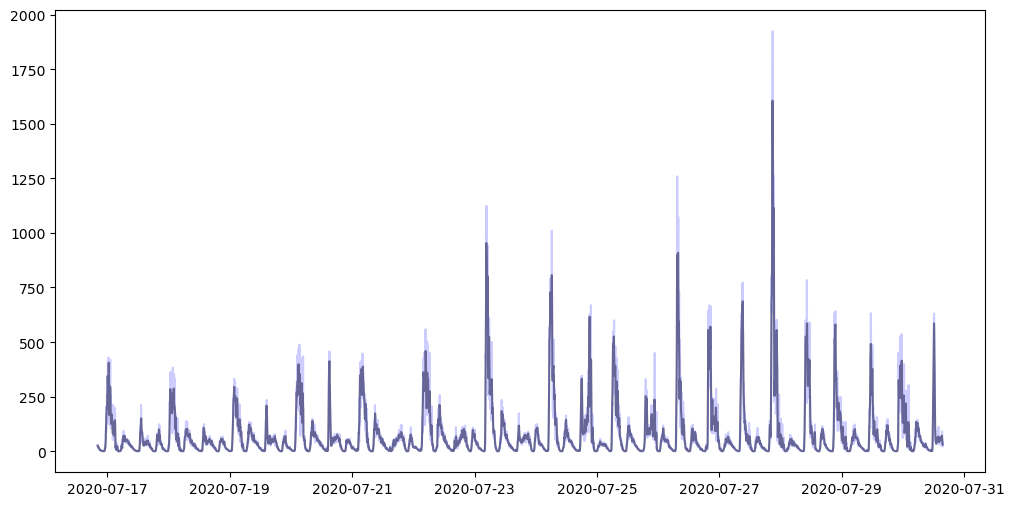

In [55]:
import matplotlib.pyplot as plt
adv_data = pd.read_csv("processed_adv_data.csv")

fig = plt.figure(figsize=(12, 6))
ax = plt.gca() 

ax.plot(pd.to_datetime(adv_data['time']), adv_data['smoothed_shear'], label='Shear', color='k', alpha=0.5)
ax.plot(pd.to_datetime(adv_data['time']), adv_data['shear'], label='Shear', color='blue', alpha=0.2)

                        time       eps      shear   uu_turb   vv_turb  \
0    2020-07-16 20:10:01.000  0.000028  28.240569  0.000822  0.000515   
1    2020-07-16 20:15:01.062  0.000022  22.019984  0.000582  0.000491   
2    2020-07-16 20:20:01.125  0.000026  26.015024  0.000890  0.000636   
3    2020-07-16 20:25:01.187  0.000019  18.956131  0.000692  0.000579   
4    2020-07-16 20:30:01.249  0.000019  18.589185  0.000534  0.000523   
...                      ...       ...        ...       ...       ...   
3973 2020-07-30 15:19:09.312  0.000091  91.132585  0.002162  0.001210   
3974 2020-07-30 15:24:09.375  0.000034  34.469022  0.001511  0.000793   
3975 2020-07-30 15:29:09.437  0.000022  21.997718  0.001209  0.000701   
3976 2020-07-30 15:34:09.500  0.000043  42.820594  0.001132  0.000701   
3977 2020-07-30 15:39:09.562  0.000028  28.134250  0.001177  0.000690   

       ww_turb   uw_turb   vw_turb   uv_turb   uu_wave   vv_wave   ww_wave  \
0     0.000254 -0.000154  0.000015 -0.000071 

In [11]:
from pytoast.ocean.adcp import ADCP
import xarray as xr
fn = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/CSF20_Channel_Time_Series/CSF20CHT01sig-b.nc"
ds = xr.open_dataset(fn, decode_times=False)
print(ds)


# print("OTHER DATA:")
# fn = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/CSF20_Shallows_Time_Series/CSF20SPT01wh-s.nc"
# ds = xr.open_dataset(fn, decode_times=False)
# print(ds)


adcp = ADCP(
    files=fn,
    name_map={
        "time": lambda x: x["time"] + x["time2"] / 86400000,
        "u1": lambda x: x["vel1_1277"] / 1000,
        "u2": lambda x: x["vel2_1278"] / 1000,
        "u3": lambda x: x["vel3_1279"] / 1000,
        "u4": lambda x: x["vel4_1280"] / 1000,
        "z": "depth",
        "transformation_matrix": "TransMatrix"
    },
    burst_dim="time",  # This ds.dims["time"] which encodes the 332 bursts, as opposed to the data vars ds["time"] and ds["time2"]
    orientation="up",
    manufacturer="nortek",
    z_convention="depth",
    decode_times=False
)

<xarray.Dataset> Size: 6GB
Dimensions:         (time: 332, sample: 7200, Tmatrix: 4, depth: 35, lat: 1,
                     lon: 1)
Coordinates:
    time            (time, sample) int32 10MB ...
  * sample          (sample) float64 58kB 1.0 2.0 3.0 ... 7.199e+03 7.2e+03
  * depth           (depth) float32 140B 10.05 9.55 9.05 ... -5.95 -6.45 -6.95
  * lat             (lat) float32 4B 37.54
  * lon             (lon) float32 4B -122.2
Dimensions without coordinates: Tmatrix
Data variables: (12/35)
    time2           (time, sample) int32 10MB ...
    TransMatrix     (Tmatrix, Tmatrix) float32 64B ...
    burst           (time) float64 3kB ...
    bindist         (depth) float32 140B ...
    vel1_1277       (time, sample, depth) float32 335MB ...
    vel2_1278       (time, sample, depth) float32 335MB ...
    ...              ...
    Status          (time, sample) float64 19MB ...
    TransmitEnergy  (time, sample) float32 10MB ...
    AccelerometerX  (time, sample) float32 10MB ...
    

/global/homes/s/siennaw/.conda/envs/jupenv3/lib/python3.14/site-packages/xarray/namedarray/core.py:261: UserWarning: Duplicate dimension names present: dimensions {'Tmatrix'} appear more than once in dims=('Tmatrix', 'Tmatrix'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immediately to become distinct, as most xarray functionality is likely to fail silently if you do not. To rename the dimensions you will need to set the ``.dims`` attribute of each variable, ``e.g. var.dims=('x0', 'x1')``.
  self._dims = self._parse_dimensions(dims)
/global/homes/s/siennaw/.conda/envs/jupenv3/lib/python3.14/site-packages/xarray/namedarray/core.py:261: UserWarning: Duplicate dimension names present: dimensions {'Tmatrix'} appear more than once in dims=('Tmatrix', 'Tmatrix'). We do not yet support duplicate dimension names, but we do allow initial construction of the object. We recommend you rename the dims immedia

In [ ]:
# ADCP 
# Pre-process the ADCP data 
from pytoast.ocean.adcp import ADCP

fn ="adcp_4pytoast.nc"

if 0: 
    fn = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/CSF20_Shallows_Time_Series/CSF20SPT01wh-b.nc"
    ds = xr.open_dataset(fn, decode_times=False)
    dates = julian_to_datetime(ds['time'].values, ds['time2']) 
    ds = ds.assign_coords(time=dates)
    ds.time.attrs = {} 
    
    ds.to_netcdf(fn)


ds = xr.open_dataset(fn, decode_times=True)
print(ds)
adcp = ADCP(fn)


In [ ]:
u = np.squeeze(dsv.u_1205)
v = np.squeeze(dsv.v_1206)
w = np.squeeze(dsv.w_1204)



fig = plt.figure(figsize=(12, 4))
ax = plt.gca()
ax.plot(time, u, label='u', color='red')
ax.plot(time, v, label='v', color='blue')
ax.plot(time, w, label='w', color='gold')
ax.grid(alpha=0.25)
# u_1205 {'units': 'cm/s', 'long_name': 'Eastward Velocity', 'name': 'u', 'generic_name': 'u', 'epic_code': np.float64(1205.0), 'sensor_type': 'Nortek Vector acoustic Doppler velocimeter', 'initial_sensor_height': np.float64(0.391), 'sample_volume_offset': np.float64(0.149), 'height_depth_units': 'm', 'serial_number': 'VEC11464', 'maximum': np.float64(31.5291660844512), 'minimum': np.float64(-28.206416202005197), 'valid_range': array([-1.,  1.]), 'range_note': 'Nominal velocity range in m/s'}
# v_1206 {'units': 'cm/s', 'long_name': 'Northward Velocity', 'name': 'v', 'generic_name': 'v', 'epic_code': np.float64(1206.0), 'sensor_type': 'Nortek Vector acoustic Doppler velocimeter', 'initial_sensor_height': np.float64(0.391), 'sample_volume_offset': np.float64(0.149), 'height_depth_units': 'm', 'serial_number': 'VEC11464', 'maximum': np.float64(20.25021995557771), 'minimum': np.float64(-23.59139729880581), 'valid_range': array([-1.,  1.]), 'range_note': 'Nominal velocity range in m/s'}
# w_1204 {'units': 'cm/s', 'long_name': 'Vertical Velocity', 
        
# for d in dsv.data_vars:
#     print(d, dsv[d].attrs)

AssertionError: 

In [ ]:
# {'CREATION_DATE': '23-Nov-2020 18:27:19', 'DATA_TYPE': 'TIME', 'DATA_SUBTYPE': 'MOORED', 'MOORING': 'CSF20SC2', 'inst_number': 'CSF20SC202', 'PROGRAM': 'Sediment Transport in Coastal Environments', 'PROJECT': 'Channel-Shallows Sediment Flocculation', 'EXPERIMENT': 'CSF20', 'Region': 'South San Francisco Bay', 'CruiseID': '2020-621-FA', 'SciPi': 'Rachel Allen, Jessica Lacy', 'DATA_ORIGIN': 'USGS/PCMSC', 'COORD_SYSTEM': 'GEOGRAPHIC', 'WATER_MASS': '?', 'COMPOSITE': np.float64(0.0), 'DATA_CMNT': 'frame mostly clear of algae', 'POS_CONST': np.float64(0.0), 'DEPTH_CONST': np.float64(0.0), 'WATER_DEPTH': np.float64(3.7869191065386003), 'DESCRIPTION': 'Coffee Table', 'DRIFTER': np.float64(0.0), 'FILL_FLAG': np.int32(0), 'start_time': '16-Jul-2020 20:10:01', 'stop_time': '30-Jul-2020 15:35:01', 'INST_TYPE': 'Nortek Vector acoustic Doppler velocimeter', 'Year': np.float64(2020.0), 'Site': 'SC2', 'platform_type': 'Tripod', 'latitude': np.float64(37.54837), 'longitude': np.float64(-122.16856), 'Deployment_date': '16-JUL-2020 20:04:45', 'Recovery_date': '30-JUL-2020  15:44:40', 'OFAFunding': 'San Francisco Estuary Institute', 'CollaboratingAgency': 'USGS CAWSC', 'WATER_DEPTH_source': 'water depth = MSL from pressure sensor', 'Conventions': 'PMEL/EPIC', 'history': array([], dtype=float64), 'baseFileName': 'SC2VEC02', 'instnum': '02', 'atmospheric_pressure_correction_method': 'none', 'orientation': 'DOWN', 'case': 'horizontal', 'probe_type': 'CABLED', 'pressure_sensor_height': np.float64(0.76), 'probe_height': np.float64(0.54), 'good_bursts': array([  63., 4040.]), 'amplitude_cutoff': np.float64(70.0), 'filename': 'CSF20SC202vec-b', 'goodbursts': array([  63.,   64.,   65., ..., 4038., 4039., 4040.], shape=(3978,)), 'magnetic_variation_at_site': np.float64(13.26), 'instmeta_VECNumberOfMeasurements': np.float64(16830757.0), 'instmeta_VECTimeOfFirstMeasurement': '7/16/2020 3:00:00 PM', 'instmeta_VECTimeOfLastMeasurement': '7/30/2020 9:25:15 PM', 'instmeta_VECSamplingRate': np.float64(16.0), 'instmeta_VECNominalVelocityRange': np.float64(1.0), 'instmeta_VECBurstInterval': np.float64(300.0), 'instmeta_VECSamplesPerBurst': np.float64(4096.0), 'instmeta_VECSamplingVolume': np.float64(14.9), 'instmeta_VECTransmitLength': np.float64(4.0), 'instmeta_VECReceiveLength': np.float64(0.01), 'instmeta_VECAnalogOutputEnabled': 'DISABLED', 'instmeta_VECAnalogInput1Sampling': 'NONE', 'instmeta_VECAnalogInput2Sampling': 'NONE', 'instmeta_VECPowerOutputEnabled': 'DISABLED', 'instmeta_VECOutputFormat': 'VECTOR', 'instmeta_VECVelocityScaling': np.float64(1.0), 'instmeta_VECPowerLevel': 'HIGH', 'instmeta_VECCoordinateSystem': 'XYZ', 'instmeta_VECSoundSpeed': 'MEASURED', 'instmeta_VECAssumedSalinity': np.float64(30.0), 'instmeta_VECistanceBetweenPings': np.float64(1.01), 'instmeta_VECNumberOfBeams': np.float64(3.0), 'instmeta_VECSoftwareVersion': '1.39', 'instmeta_VECeploymentName': 'SC2VEC', 'instmeta_VECWrapMode': 'OFF', 'instmeta_VECeploymentTime': '7/16/2020 3:00:00 PM', 'instmeta_VECComment1': 'CSF20 SC2 sv 40 cmab', 'instmeta_VECComment2': 'no seapoint', 'instmeta_VECInstrumentSerialNumber': 'VEC11464', 'instmeta_VECRevisionNumber': '3886 MByte', 'instmeta_VECFirmwareVersion': '3.42', 'instmeta_PressureSensor': '0 0', 'instmeta_Compass': '17 ', 'instmeta_TiltSensor': 'YES', 'instmeta_VECFrequency': np.float64(6000.0), 'instmeta_VECHeadSerialNumber': 'VCH 4997', 'instmeta_VECTransformationMatrix': array([ 2.7451e+00, -1.5000e-03, -3.4910e-01, -1.3733e+00, -2.3403e+00,
#        -3.4060e-01, -1.3757e+00,  2.3416e+00, -3.4130e-01]), 'nbursts': np.float64(3978.0), 'burstlength': np.float64(4096.0), 'velocity_height': np.float64(0.391), 'VECNumberOfMeasurements': np.float64(16830757.0), 'VECTimeOfFirstMeasurement': '7/16/2020 3:00:00 PM', 'VECTimeOfLastMeasurement': '7/30/2020 9:25:15 PM', 'VECSamplingRate': np.float64(16.0), 'VECNominalVelocityRange': np.float64(1.0), 'VECBurstInterval': np.float64(300.0), 'VECSamplesPerBurst': np.float64(4096.0), 'VECSamplingVolume': np.float64(14.9), 'VECTransmitLength': np.float64(4.0), 'VECReceiveLength': np.float64(0.01), 'VECAnalogOutputEnabled': 'DISABLED', 'VECAnalogInput1Sampling': 'NONE', 'VECAnalogInput2Sampling': 'NONE', 'VECPowerOutputEnabled': 'DISABLED', 'VECOutputFormat': 'VECTOR', 'VECVelocityScaling': np.float64(1.0), 'VECPowerLevel': 'HIGH', 'VECCoordinateSystem': 'XYZ', 'VECSoundSpeed': 'MEASURED', 'VECAssumedSalinity': np.float64(30.0), 'VECistanceBetweenPings': np.float64(1.01), 'VECNumberOfBeams': np.float64(3.0), 'VECSoftwareVersion': '1.39', 'VECeploymentName': 'SC2VEC', 'VECWrapMode': 'OFF', 'VECeploymentTime': '7/16/2020 3:00:00 PM', 'VECComment1': 'CSF20 SC2 sv 40 cmab', 'VECComment2': 'no seapoint', 'VECInstrumentSerialNumber': 'VEC11464', 'VECRevisionNumber': '3886 MByte', 'VECFirmwareVersion': '3.42', 'PressureSensor': '0 0', 'Compass': '17 ', 'TiltSensor': 'YES', 'VECFrequency': np.float64(6000.0), 'VECHeadSerialNumber': 'VCH 4997', 'VECTransformationMatrix': array([ 2.7451e+00, -1.5000e-03, -3.4910e-01, -1.3733e+00, -2.3403e+00,
#        -3.4060e-01, -1.3757e+00,  2.3416e+00, -3.4130e-01]), 'WATER_DEPTH_datum': 'MSL'}

In [ ]:
# LISST data 
    # Process_Description: Files were named with a convention that uses a 12- to 15-digit alpha-numeric code. 
    #     The first three characters for this dataset are all 'CSF' for the experiment name; the fourth and fifth positions represent the calendar year in which the data were collected (20, 2020); the sixth, seventh and eighth characters are an alphanumeric code for the platform name (CHT, SC1, etc.); the ninth and tenth characters represent the instrument position on the platform, where 01 is the top-most. Next is a two- or three-character code for the instrument type (vec, Nortek's Acoustic Doppler Velocimeter; alt, EofE Ultrasonics' altimeter; wh, RDInstrument's acoustic doppler current profile current data; pt, RBR's bursting pressure sensor with temperature; ctd, RBR's CTD; Tu, RBR's Virtuoso turbidity logger; ls, Sequoia Scientific's LISST; sig, Nortek's Signature1000 ADCP). There are an additional 2-4 characters for instruments that collect in a bursting pattern to indicate whether the file includes the raw burst data (-b), the statistics of the burst (-s), or the wave data (-wvs). This indicator is omitted if there is no bursting pattern.
    #     Process_Date: 20210301

fn = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/CSF20_Shallows_Time_Series/CSF20SC104ls-b.nc"
lds = xr.open_dataset(fn, decode_times=False)



ldates = julian_to_datetime(lds['time'].values, lds['time2'].values)
# dates = pd.to_datetime(ds['time'].values, unit='D', origin='julian')
# seconds = pd.to_timedelta(ds['time2'].values, unit='ms')
# dates = dates + seconds
print(lds)
lds = lds.isel(depth=0)
# d50 = ds['D50'].isel(depth=0)
# print(d50)


stds = lds['D50'].std(axis=1) 

d50 = lds['D50'].mean(axis=1)


assert(False)

for d in range(17, 28):

    fig = plt.figure(figsize=(10,4))
    ax = plt.gca()

    ax.fill_between(dates, np.squeeze(d50-stds), np.squeeze(d50+stds), color='#CBE2FE', alpha=0.55, label="Standard Deviation")

    ax.plot(dates, d50, 'o', color='#10288C', label="D$_{50}$")
    # fill between

    ax.grid(alpha=0.25)
    ax.set_ylabel('D$_{50}$ ($\mu$m)')
    ax.set_ylim(0,)
    ax.set_title('D$_{50}$ from LISST')
    format_date_ax(ax)
    ax.set_xlim(pd.to_datetime('2020-07-%d' % d), pd.to_datetime('2020-07-%d' % (d+1)))
    ax.legend()

#### 


<xarray.Dataset> Size: 229MB
Dimensions:     (time: 3977, sample: 120, depth: 1, size_class: 36, CDF: 37,
                 lat: 1, lon: 1)
Coordinates:
  * time        (time) int32 16kB 2459047 2459047 2459047 ... 2459061 2459061
  * sample      (sample) int32 480B 1 2 3 4 5 6 7 ... 115 116 117 118 119 120
  * depth       (depth) float32 4B 3.5
  * size_class  (size_class) float32 144B 1.21 1.6 1.89 ... 324.0 386.0 459.0
    CDF         (time, sample, depth, CDF) float32 71MB ...
  * lat         (lat) float32 4B 37.55
  * lon         (lon) float32 4B -122.2
Data variables: (12/13)
    time2       (time) int32 16kB 72600000 72900000 ... 55499999 55800000
    vconc       (time, sample, depth, size_class) float64 137MB ...
    ltrans      (time, sample, depth) float32 2MB ...
    batt        (time, sample, depth) float32 2MB ...
    lref        (time, sample, depth) float32 2MB ...
    ptrans      (time, sample, depth) float32 2MB ...
    ...          ...
    T_20        (time, sample, de

<>:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1163968/2666690499.py:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel('D$_{50}$ ($\mu$m)')
/tmp/ipykernel_1163968/2666690499.py:38: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel('D$_{50}$ ($\mu$m)')


AssertionError: 

In [8]:
import datetime


fn = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/CSF20_Shallows_Time_Series/CSF20SPT01wh-b.nc"
ds = xr.open_dataset(fn, decode_times=False)



# Time (UTC) in True Julian Days: 2440000 = 0000 h on May 23, 1968
dates = julian_to_datetime(ds['time'].values, ds['time2']) 
# seconds = pd.to_timedelta(ds['time2'], unit='ms')
# dates = dates + seconds

In [ ]:
if 1:
    
    rds = ds.assign_coords(time=dates)

    rds = rds.resample(time='5min').mean()
    rds.time.attrs = {}
    rds= rds.drop_vars('time2')
    rds.to_netcdf("resampled_adcp_usgs.nc")
assert(False)

AssertionError: 

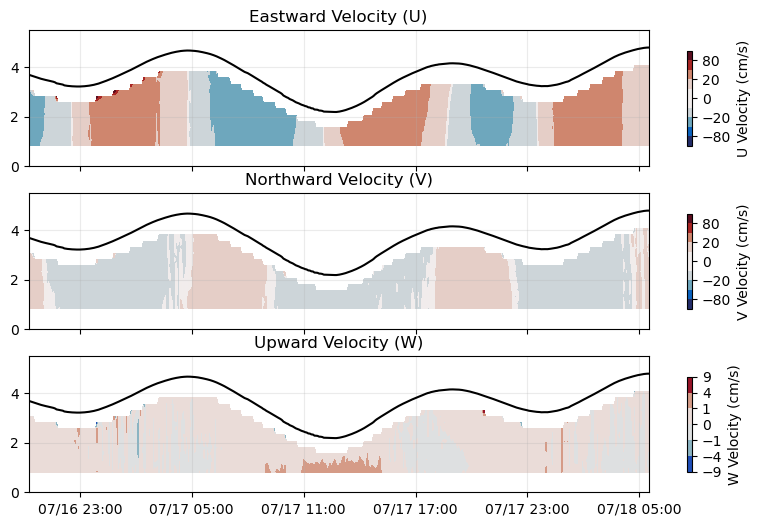

In [17]:
fig, axs = plt.subplots(3, 1, figsize=(10, 6), sharex=True)


rds = xr.open_dataset("resampled_adcp_usgs.nc", decode_times=True)
low, high = 0, 400
rtime = rds.time.values[low:high]
offset= 3.537306921274909


axs[0].set_xlim(rtime[0], rtime[-1])
levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]

velocity = np.squeeze(rds.u_1205)
z = ds.depth.values
h = axs[0].contourf(rtime, -z + offset, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[0].set_title('Eastward Velocity (U)')

def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)


depths =  np.squeeze(rds.P_1.values[low:high]) #+ 0.41

axs[0].plot(rtime, depths, color='k', label='Depth')
axs[1].plot(rtime, depths, color='k', label='Depth')
axs[2].plot(rtime, depths, color='k', label='Depth')

velocity = np.squeeze(rds.v_1206)
h = axs[1].contourf(rtime, -z + offset, velocity[low:high,:].T,  cmap=cmo.cm.balance, levels=levels)

plt.colorbar(h, label='V Velocity (cm/s)', shrink=0.7)
axs[1].set_title('Northward Velocity (V)')

vmin, vmax = -10, 10
velocity = np.squeeze(rds.w_1204)

levels = [-9, -4, -1, 0, 1, 4, 9]
h = axs[2].contourf(rtime, -z + offset, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='W Velocity (cm/s)', shrink=0.7)
axs[2].set_title('Upward Velocity (W)')

for ax in axs:
    ax.grid(alpha=0.25)
    format_date_ax(ax, int=6)
    ax.set_ylim(0, 5.5)


3973


<>:41: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:41: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_1163968/627479435.py:41: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_ylabel('D$_{50}$ ($\mu$m)')


(10.0, 300.0)

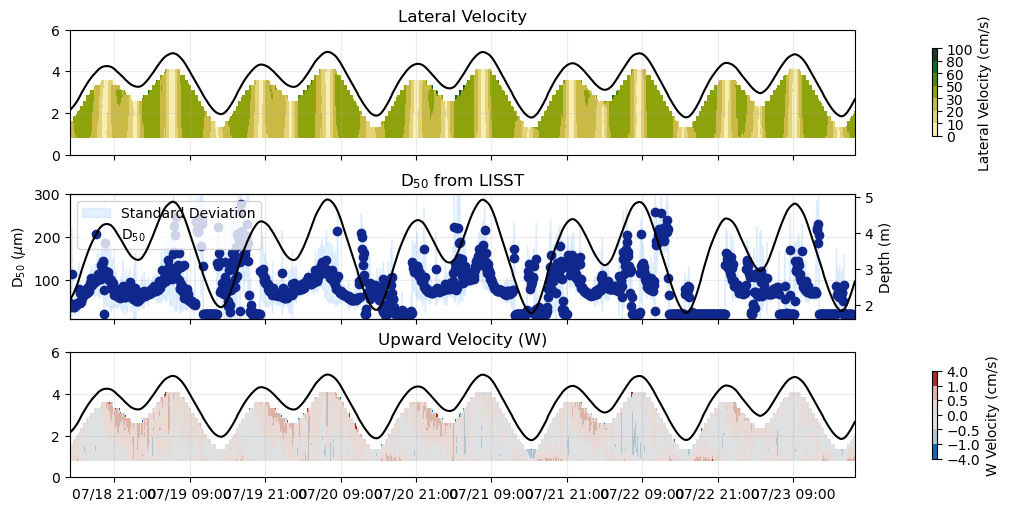

In [50]:
def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)


fig, axs = plt.subplots(3, 1, figsize=(10, 5), sharex=True, constrained_layout=True)

print(len(rds.time.values))
low, high =0, 2000
3973
rtime = rds.time.values[low:high]

levels = [ 0,10, 20, 30, 50, 60, 80, 100]

lateral = np.squeeze(rds.u_1205.values[low:high])**2 + np.squeeze(rds.v_1206.values[low:high])**2
lateral = np.sqrt(lateral)
                                # blanking distance         
depths =  np.squeeze(rds.P_1.values[low:high])  #+ 0.41

                    # offset from bed
axs[0].plot(rtime, depths, color='k', label='Depth')
axs[2].plot(rtime, depths, color='k', label='Depth')


axs[0].set_xlim(rtime[500], rtime[-1])
h = axs[0].contourf(rtime, -z + offset,  lateral[low:high,:].T, cmap=cmo.cm.speed, levels=levels)
plt.colorbar(h, label='Lateral Velocity (cm/s)', shrink=0.7)
axs[0].set_title('Lateral Velocity')

velocity = np.squeeze(rds.w_1204)
levels = [-4, -1, -0.5, 0, 0.5, 1, 4]
h = axs[2].contourf(rtime, -z + offset, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='W Velocity (cm/s)', shrink=0.7)
axs[2].set_title('Upward Velocity (W)')

ax = axs[1]
ax.fill_between(ldates, np.squeeze(d50-stds), np.squeeze(d50+stds), color='#CBE2FE', alpha=0.55, label="Standard Deviation")
ax.plot(ldates, d50, 'o', color='#10288C', label="D$_{50}$")
ax.grid(alpha=0.25)
ax.set_ylabel('D$_{50}$ ($\mu$m)')
ax.set_ylim(0,)
ax.set_title('D$_{50}$ from LISST')
format_date_ax(ax)
ax.legend(loc='upper left')

ax2 = axs[1].twinx()
ax2.set_ylabel('Depth (m)')
ax2.plot(rtime, depths, color='k', label='Depth')

for ax in axs:
    # ax.plot(rtime, depths, color='k', label='Depth')
    ax.grid(alpha=0.25)
    format_date_ax(ax, int=12)
    ax.set_ylim(0, 6)

axs[1].set_ylim(10, 300)

AttributeError: 'Dataset' object has no attribute 'u_1205'

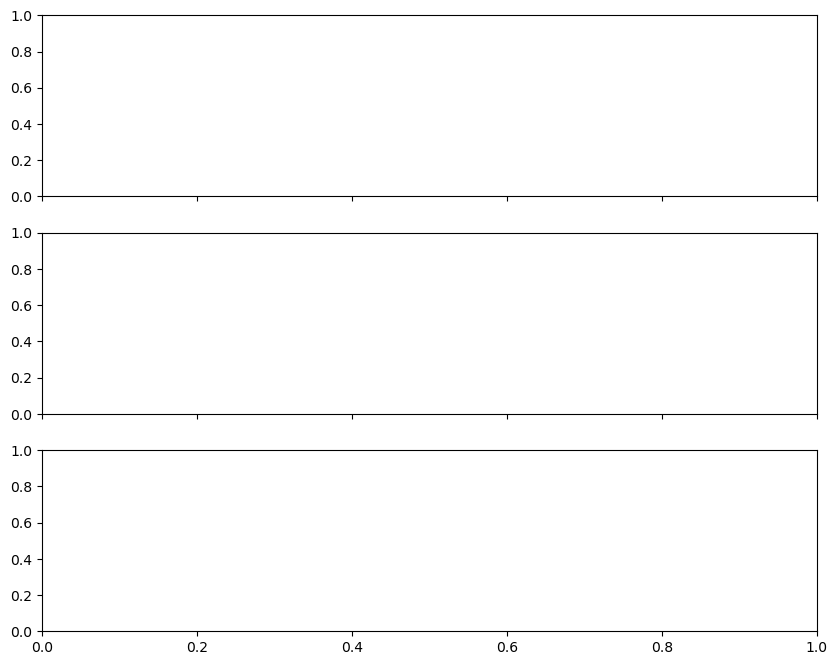

In [29]:
fig, axs = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

vmin, vmax = -40, 40
velocity = np.squeeze(ds.u_1205)
z = ds.depth.values

low, high = 0, 3600*24

axs[0].set_xlim(dates[0], dates[high])
levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]

h = axs[0].contourf(dates[low:high], z, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='U Velocity (cm/s)', shrink=0.7)
axs[0].set_title('Eastward Velocity (U)')

def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)

vmin, vmax = -20, 20
velocity = np.squeeze(ds.v_1206)
h = axs[1].contourf(dates[low:high], z, velocity[low:high,:].T,  cmap=cmo.cm.balance, levels=levels)

# h = axs[1].pcolormesh(dates[low:high], z, velocity[low:high,:].T, cmap=cmo.cm.balance, vmin=vmin, vmax=vmax)
plt.colorbar(h, label='V Velocity (cm/s)', shrink=0.7)
axs[1].set_title('Northward Velocity (V)')


vmin, vmax = -10, 10
velocity = np.squeeze(ds.w_1204)

levels = [-20, -15,-10, -5, -1, 0, 1, 5, 10, 15, 20]
# h = axs[2].pcolormesh(dates[low:high], z, velocity[low:high,:].T, cmap=cmo.cm.balance, vmin=vmin, vmax=vmax)
h = axs[2].contourf(dates[low:high], z, velocity[low:high,:].T, cmap=cmo.cm.balance, levels=levels)
plt.colorbar(h, label='W Velocity (cm/s)', shrink=0.7)
axs[2].set_title('Upward Velocity (W)')

for ax in axs:
    ax.grid(alpha=0.25)
    format_date_ax(ax, int=6)
    ax.set_ylim(0, 4)


KeyboardInterrupt: 

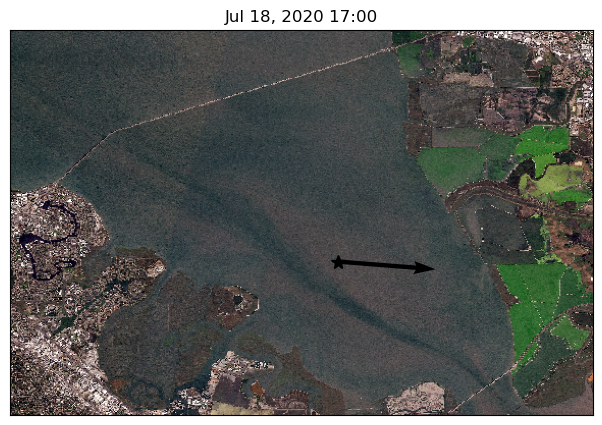

In [ ]:

basemap = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/ssfb_2.tiff"

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import rasterio as rio # Libraries for showing a tiff file
from rasterio.plot import show 
import time 
from IPython.display import clear_output, display
# from pyproj import Proj, transform
# import geopandas as gpd 



lat, lon = ds.lat.values[0], ds.lon.values[0]

####
# axs[0].set_xlim(dates[0], dates[high])
# levels = [-100, -80, -50, -20, -1, 0, 1, 20, 50, 80, 100]


def format_date_ax(ax, int=1):
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=int))
    date_format = mdates.DateFormatter('%m/%d %H:%M')
    ax.xaxis.set_major_formatter(date_format)


rolling_time = rds.time.values 
u = np.squeeze(rds.u_1205.mean(dim='depth').values)
v = np.squeeze(rds.v_1206.mean(dim='depth').values)
print(u.shape, v.shape)
print(rolling_time)
# h = axs[1].contourf(, z, velocity[low:high,:].T,  cmap=cmo.cm.balance, levels=levels)
# dates[low:high], 
###

it = 0 


# fig, axs = plt.subplots(figsize=(10,5), nrows = 1, ncols = 2, gridspec_kw={'width_ratios': [ 1, 5]})
fig = plt.figure(figsize=(10,5))
ax = plt.gca()
# Show the basemap
with rio.open(basemap) as src:
    crs = src.crs
    show(src, ax=ax)
    ax.set_xticks([])
    ax.set_yticks([])
    # assert(False)
    ax.plot(lon, lat, 'k*', markersize=10)

for it in range(0, len(rolling_time), 1):
    times = rolling_time[it]
    times = pd.to_datetime(times)
    print(times)
    ax.set_title("%s" % times.strftime("%B %d, %Y %H:%M"))
    h = plt.quiver(lon, lat, u[it], v[it], angles='xy', color='k', scale=200)
    print(u[it], v[it])
    clear_output(wait=True)  # Clear the previous plot
    display(fig)             # Display the current plot
    time.sleep(0.001)
    h.remove()  # Remove the quiver plot for the next iteration
        # axs[2].set_title("Site: %s (%s)" % (name2fullname[site], date2fullname[date]))
        # s

<xarray.DataArray 'lat' (lat: 1)> Size: 4B
array([37.54722], dtype=float32)
Coordinates:
  * lat      (lat) float32 4B 37.55
Attributes:
    FORTRAN_format:  F10.2
    units:           degree_north
    type:            EVEN
    epic_code:       500.0
    name:            LAT
    long_name:       LATITUDE
    generic_name:    lat
    datum:           NAD83
<xarray.DataArray 'lon' (lon: 1)> Size: 4B
array([-122.16842], dtype=float32)
Coordinates:
  * lon      (lon) float32 4B -122.2
Attributes:
    FORTRAN_format:  F10.2
    units:           degree_east
    type:            EVEN
    epic_code:       502.0
    name:            LON
    long_name:       LONGITUDE
    generic_name:    lon
    datum:           NAD83


<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_2146068/3040181040.py:18: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  ax.set_xlabel('D$_{50}$ ($\mu$m)')


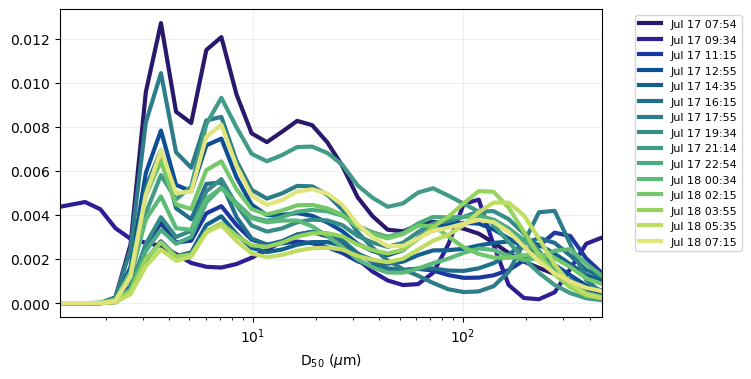

In [ ]:
import cmocean as cmo
# (3994, 120, 1, 37)
# print(ds.CDF.shape)

x = ds.size_class.values 
fig = plt.figure(figsize=(7,4))
ax = plt.gca()

for i in range(1, 300, 20):
    v = ds.CDF.isel(time=i, sample=0, depth=0).values

    pdf = np.gradient(v[:-1], x)
    # ax.boxplot(v.values, positions=[i], widths=5.5)
    ax.plot(x, pdf, '-', color=cmo.cm.haline(i/300), linewidth=3, label=dates[i].strftime("%b %d %H:%M"))
    # ax.plot(i, v.values, 'o')
    # print(v)
    
ax.set_xlabel('D$_{50}$ ($\mu$m)')
ax.set_xlim(x[0], x[-1])
ax.grid(alpha=0.2)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

ax.set_xscale('log')

(0.0, 346.9516315460205)

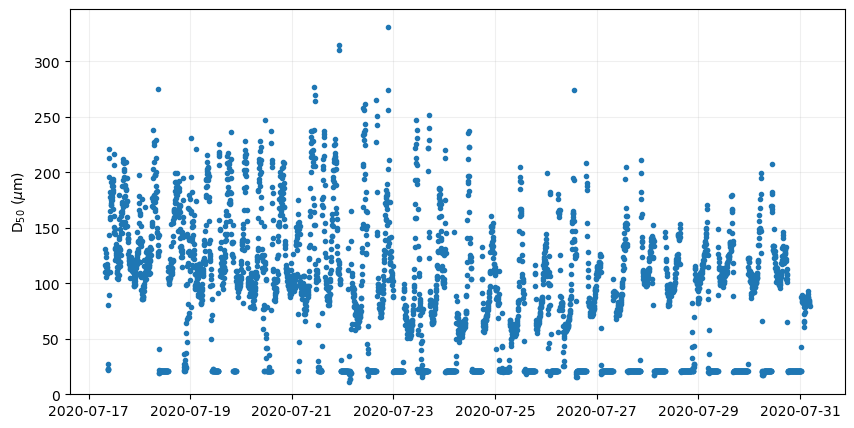

In [ ]:
    #     Process_Date: 20210301
import pandas as pd 
fn = "/global/homes/s/siennaw/scratch/siennaw/data/usgs/CSF20_Channel_Time_Series/CSF20CHT05ls-s.nc"
ds = xr.open_dataset(fn, decode_times=False)

fig = plt.figure(figsize=(10,5))
ax = plt.gca()


dates = pd.to_datetime(ds['time'].values, unit='D', origin='julian')


ts = ds['D50'].values
ts[ts<1] = np.nan
ax.plot(dates, ts, '.')
ax.grid(alpha=0.2)
    # ax.plot(i, v.values, 'o')
    # print(v)
ax.set_ylabel(r'D$_{50}$ ($\mu$m)')
ax.set_ylim(0,)